<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/CUSTOMER_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Generating dataset...
Dataset shape: (500, 2)
2. Running NumPy K-Means...
Iter 1: WCSS=12951.0381, shift=11.666825
Iter 2: WCSS=6506.0783, shift=3.895684
Iter 3: WCSS=2507.7796, shift=4.605178
Iter 4: WCSS=607.2898, shift=1.732931
Iter 5: WCSS=607.2898, shift=0.000000
NumPy K-Means Results:
Final WCSS: 607.2898
Runtime: 0.0036s
Iterations: 5
3. Running sklearn K-Means...
sklearn K-Means Results:
Final WCSS: 3072.5450
Runtime: 0.0054s


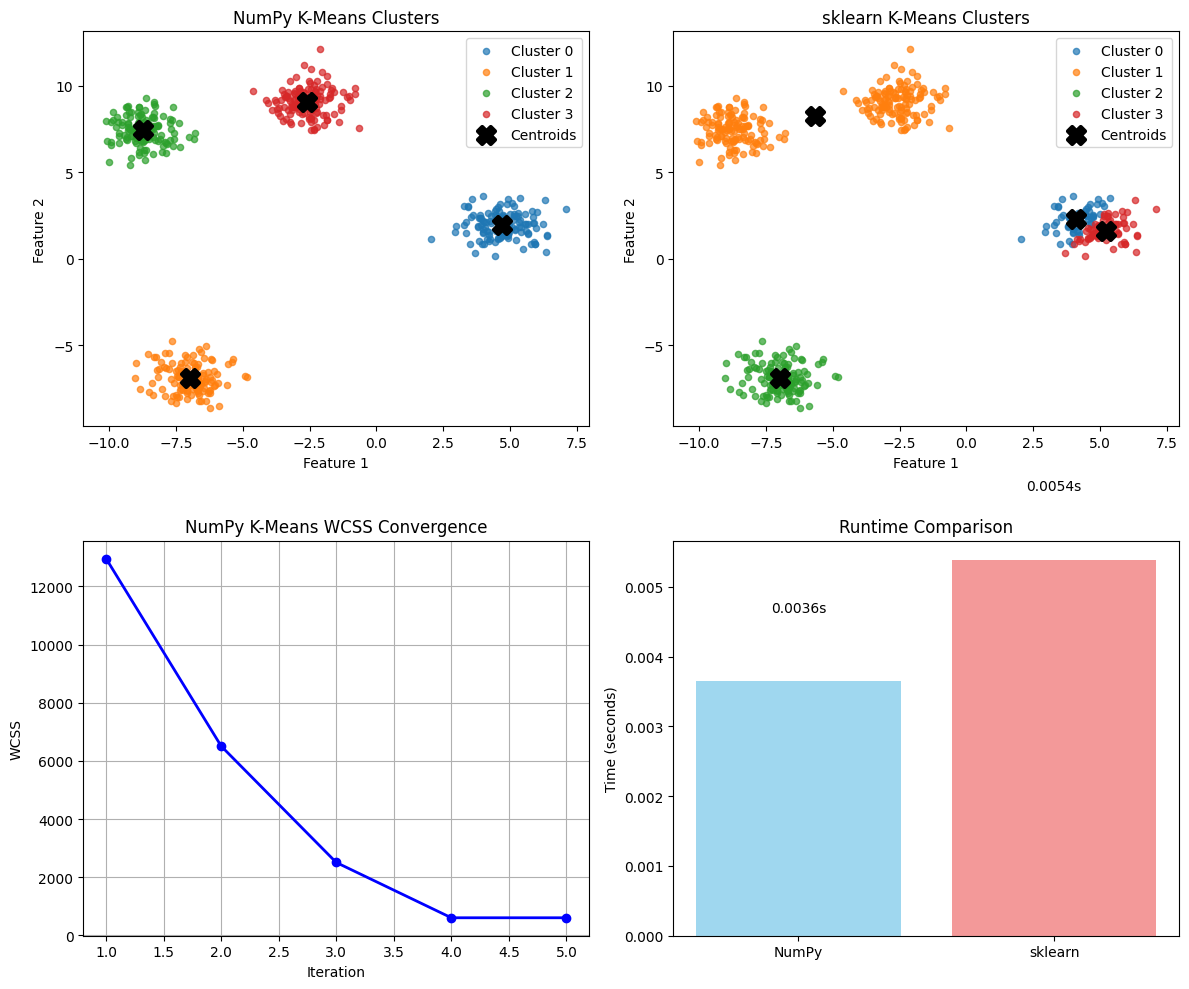

✓ All required components completed:
  - Pure NumPy K-Means (init, assign, update, WCSS)
  - sklearn comparison with runtime
  - 4 Matplotlib visualizations
  - WCSS convergence tracking


In [18]:
# =====================================================
# K-Means Clustering from Scratch using Pure NumPy
# =====================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# =====================================================
# 1. DATASET GENERATION
# =====================================================
print("1. Generating dataset...")
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)
print(f"Dataset shape: {X.shape}")

# =====================================================
# 2. PURE NUMPY K-MEANS IMPLEMENTATION
# =====================================================
def initialize_centroids(X, k, random_state=42):
    """Initialize K centroids randomly from data points"""
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], size=k, replace=False)
    return X[idx].copy()

def assign_clusters(X, centroids):
    """Assign each point to nearest centroid (squared Euclidean distance)"""
    # X: (n_samples, n_features), centroids: (k, n_features)
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(dists, axis=1)
    return labels

def update_centroids(X, labels, k):
    """Update centroids as mean of assigned points"""
    n_features = X.shape[1]
    centroids = np.zeros((k, n_features))
    for i in range(k):
        points = X[labels == i]
        if len(points) == 0:
            centroids[i] = X[np.random.randint(0, X.shape[0])]
        else:
            centroids[i] = points.mean(axis=0)
    return centroids

def compute_wcss(X, labels, centroids):
    """Compute Within-Cluster Sum of Squares (inertia)"""
    wcss = 0.0
    for i in range(centroids.shape[0]):
        points = X[labels == i]
        if len(points) > 0:
            wcss += np.sum((points - centroids[i])**2)
    return wcss

def kmeans_numpy(X, k, max_iters=100, tol=1e-4, random_state=42, verbose=False):
    """Complete K-Means algorithm using only NumPy"""
    centroids = initialize_centroids(X, k, random_state)
    wcss_history = []

    for it in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        wcss = compute_wcss(X, labels, new_centroids)
        wcss_history.append(wcss)

        shift = np.linalg.norm(new_centroids - centroids)
        if verbose:
            print(f"Iter {it+1}: WCSS={wcss:.4f}, shift={shift:.6f}")
        if shift < tol:
            break
        centroids = new_centroids

    return labels, centroids, wcss_history

# =====================================================
# 3. RUN NUMPY K-MEANS
# =====================================================
print("2. Running NumPy K-Means...")
k = 4
start = time.time()
labels_np, centroids_np, wcss_hist_np = kmeans_numpy(
    X, k, max_iters=100, tol=1e-4, random_state=42, verbose=True
)
time_np = time.time() - start
final_wcss_np = wcss_hist_np[-1]

print(f"NumPy K-Means Results:")
print(f"Final WCSS: {final_wcss_np:.4f}")
print(f"Runtime: {time_np:.4f}s")
print(f"Iterations: {len(wcss_hist_np)}")

# =====================================================
# 4. SKLEARN COMPARISON
# =====================================================
print("3. Running sklearn K-Means...")
start = time.time()
kmeans_skl = KMeans(n_clusters=k, init="random", n_init=1,
                    max_iter=100, tol=1e-4, random_state=42)
kmeans_skl.fit(X)
time_skl = time.time() - start
final_wcss_skl = kmeans_skl.inertia_

print(f"sklearn K-Means Results:")
print(f"Final WCSS: {final_wcss_skl:.4f}")
print(f"Runtime: {time_skl:.4f}s")

# =====================================================
# 5. VISUALIZATIONS
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: NumPy K-Means Clusters
for i in range(k):
    axes[0,0].scatter(X[labels_np == i, 0], X[labels_np == i, 1],
                     s=20, label=f'Cluster {i}', alpha=0.7)
axes[0,0].scatter(centroids_np[:, 0], centroids_np[:, 1],
                 c='black', s=150, marker='X', linewidths=3, label='Centroids')
axes[0,0].set_title('NumPy K-Means Clusters')
axes[0,0].legend()
axes[0,0].set_xlabel('Feature 1')
axes[0,0].set_ylabel('Feature 2')

# Plot 2: sklearn K-Means Clusters
for i in range(k):
    axes[0,1].scatter(X[kmeans_skl.labels_ == i, 0], X[kmeans_skl.labels_ == i, 1],
                     s=20, label=f'Cluster {i}', alpha=0.7)
axes[0,1].scatter(kmeans_skl.cluster_centers_[:, 0], kmeans_skl.cluster_centers_[:, 1],
                 c='black', s=150, marker='X', linewidths=3, label='Centroids')
axes[0,1].set_title('sklearn K-Means Clusters')
axes[0,1].legend()
axes[0,1].set_xlabel('Feature 1')
axes[0,1].set_ylabel('Feature 2')

# Plot 3: WCSS Convergence
axes[1,0].plot(range(1, len(wcss_hist_np)+1), wcss_hist_np, 'bo-', linewidth=2)
axes[1,0].set_title('NumPy K-Means WCSS Convergence')
axes[1,0].set_xlabel('Iteration')
axes[1,0].set_ylabel('WCSS')
axes[1,0].grid(True)

# Plot 4: Runtime Comparison
methods = ['NumPy', 'sklearn']
times = [time_np, time_skl]
axes[1,1].bar(methods, times, color=['skyblue', 'lightcoral'], alpha=0.8)
axes[1,1].set_title('Runtime Comparison')
axes[1,1].set_ylabel('Time (seconds)')
for i, t in enumerate(times):
    axes[1,1].text(i, t + 0.001, f'{t:.4f}s', ha='center')

plt.tight_layout()
plt.show()

print("✓ All required components completed:")
print("  - Pure NumPy K-Means (init, assign, update, WCSS)")
print("  - sklearn comparison with runtime")
print("  - 4 Matplotlib visualizations")
print("  - WCSS convergence tracking")